In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import torch
import sys
from scipy import stats

# Increase the font scale for seaborn
sns.set(font_scale=1.5)  # Adjust this value to increase or decrease font size
sns.set_style("white")  # Set the background to white

sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/')
from simulate_ALBF_calibration_eval import ALBFCalibrationAnalysis

In [38]:
# Main path set up
main_path="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/2025/manuscript_sim_analysis/0130"

# Choose which simulation directory to analyze 
dir_analyze="analysis_20250130_115958_PropNeg_0.5_K_2_NoWaypoints_Prior_NoGlobalPrior_NumEpochs_300_LearnedConc_Inits_2_NoCellType_Random_48326"

# Set up the path to the simulation directory
sim_dir=os.path.join(main_path,dir_analyze)

# Print the names of the files in the simulation directory
files = os.listdir(sim_dir)
print(files)

['random_init_35229_loss_curve.png', 'clustermap.png', 'losses.png', 'assignment_correlations.png', 'est_deltapsi_vs_difference.png', 'pi_barplot.png', 'nmf_clustermap.png', 'nmf_umap.png.pdf', 'ALBF_scores.csv', 'albf_vs_difference.png', 'cell_type_psi_df.csv', 'random_init_83543_loss_curve.png', 'final_results.csv', 'ALBF_report.txt', 'umap.png.pdf', 'roc_curve.png', 'est_deltapsi_vs_difference.pdf', 'parameters.json', 'precision_recall_curve.png', 'analysis_report.txt', 'precision_recall_curve.pdf', 'ALBF_score_distribution.png']


In [39]:
# Original PSI_df from simulation
PSI_df = pd.read_csv(os.path.join(sim_dir, "cell_type_psi_df.csv"))

In [40]:
PSI_df

,index,0,1,junction_id_index,junction_id,sample_label,Cluster,difference,true_label
0,0,0.434318,0.021341,0,chr10_100080130_100080856_+,positive,35178,0.412977,positive
1,1,0.131364,0.957318,1,chr10_100080130_100087346_+,positive,35178,0.825954,positive
2,2,0.434318,0.021341,2,chr10_100080940_100087346_+,positive,35178,0.412977,positive
3,0,0.239581,0.472244,3,chr10_100478022_100485050_-,positive,37286,0.232663,positive
4,1,0.520838,0.055513,4,chr10_100478022_100487161_-,positive,37286,0.465326,positive
...,...,...,...,...,...,...,...,...,...
15889,1,0.033668,0.942670,15889,chrY_898115_899427_+,positive,62094,0.909003,positive
15890,2,0.483166,0.028665,15890,chrY_898627_899427_+,positive,62094,0.454501,positive
15891,0,0.484853,0.127535,15891,chrY_900613_910447_+,positive,62095,0.357318,positive
15892,1,0.030294,0.744930,15892,chrY_910586_910656_+,positive,62095,0.714636,positive


In [41]:
PSI_df[PSI_df["true_label"] == "negative"]

,index,0,1,junction_id_index,junction_id,sample_label,Cluster,difference,true_label
6,0,0.056816,0.056816,6,chr10_100578431_100582262_-,negative,37477,0.0,negative
7,1,0.886367,0.886367,7,chr10_100578431_100583913_-,negative,37477,0.0,negative
8,2,0.056816,0.056816,8,chr10_100582322_100583913_-,negative,37477,0.0,negative
17,0,0.133713,0.133713,17,chr10_106903705_106904816_+,negative,35978,0.0,negative
18,1,0.732573,0.732573,18,chr10_106903705_106906365_+,negative,35978,0.0,negative
...,...,...,...,...,...,...,...,...,...
15883,1,0.953625,0.953625,15883,chrY_1168185_1169964_-,negative,62114,0.0,negative
15884,2,0.023188,0.023188,15884,chrY_1169257_1169964_-,negative,62114,0.0,negative
15885,0,0.173402,0.173402,15885,chrY_1280439_1282900_-,negative,62124,0.0,negative
15886,1,0.653196,0.653196,15886,chrY_1280439_1284321_-,negative,62124,0.0,negative


In [42]:
PSI_df.sample_label.value_counts()

sample_label
positive    7947
negative    7947
Name: count, dtype: int64

In [43]:
# let's load the final_results.csv file 
albf_scores = pd.read_csv(os.path.join(sim_dir, "ALBF_scores.csv"))
# rename the first two columns to be sim_psi_1 and sim_psi_2
albf_scores = albf_scores.rename(columns={"0": "latent_psi_1", "1": "latent_psi_2"})
albf_scores.head()

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label
0,0.014866,0.434577,0,70.459130,0.412977,positive,35178,1,0.419711,1
1,0.968705,0.120413,1,114.613780,0.825954,positive,35178,1,0.848292,1
2,0.017155,0.439537,2,63.304916,0.412977,positive,35178,1,0.422381,1
3,0.481497,0.227161,3,5.188319,0.232663,positive,37286,1,0.254336,1
4,0.053488,0.520464,4,22.277729,0.465326,positive,37286,1,0.466976,1


In [44]:
# How many ALBF values less than 1 
print("Number of ALBF values less than 1: ", len(albf_scores[albf_scores["ALBF"] < 1]))
# How many ALBF values greater than 1
print("Number of ALBF values greater than 1: ", len(albf_scores[albf_scores["ALBF"] > 1]))
# Proportion of ALBF values less than 1
print("Proportion of ALBF values less than 1: ", len(albf_scores[albf_scores["ALBF"] < 1])/len(albf_scores))

Number of ALBF values less than 1:  8686
Number of ALBF values greater than 1:  7208
Proportion of ALBF values less than 1:  0.5464955329054989


In [45]:
def analyze_null_albf(df):
    """
    Analyze ALBF distribution for negative junctions
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing 'ALBF' and 'true_label' columns
    
    Returns
    -------
    dict
        Dictionary containing null distribution parameters
    """
    # Get ALBF values for negative junctions
    null_albf = df[df['true_label'] == 'negative']['ALBF']
    
    # Fit normal distribution to null ALBFs
    mu, std = stats.norm.fit(null_albf)
    
    # Test for normality
    _, norm_pval = stats.normaltest(null_albf)
    
    # Create visualization
    plt.figure(figsize=(10, 6))
    
    # Plot histogram of null ALBF values
    sns.histplot(null_albf, bins=30, color='blue', alpha=0.5, label='Observed')
    
    # Plot fitted normal distribution
    x = np.linspace(null_albf.min(), null_albf.max(), 100)
    plt.plot(x, stats.norm.pdf(x, mu, std) * len(null_albf) * (null_albf.max() - null_albf.min()) / 30,
             'r-', label='Fitted Normal')
    
    plt.title(f'Distribution of ALBF Values for Negative Junctions\nμ={mu:.2f}, σ={std:.2f}, p={norm_pval:.2e}')
    plt.xlabel('ALBF')
    plt.ylabel('Count')
    plt.legend()
    
    # Calculate percentiles for potential thresholds
    percentiles = [90, 95, 99]
    thresholds = np.percentile(null_albf, percentiles)
    
    return {
        'mu': mu,
        'std': std,
        'normality_pvalue': norm_pval,
        'thresholds': dict(zip(percentiles, thresholds))
    }

In [46]:
albf_scores.sort_values(by=["true_label", "ALBF"], ascending=[True, False], inplace=True)
albf_scores

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label
6799,0.190419,0.941792,6799,2.810358,0.000000,negative,1867,0,0.751373,1
6798,0.280693,0.025431,6798,1.387880,0.000000,negative,1867,0,0.255263,1
6800,0.339205,0.034806,6800,1.373499,0.000000,negative,1867,0,0.304399,1
415,0.998706,0.978383,415,1.373440,0.000000,negative,37583,0,0.020323,1
9150,0.000486,0.000120,9150,0.972405,0.000000,negative,9976,0,0.000366,1
...,...,...,...,...,...,...,...,...,...,...
9443,0.292546,0.292563,9443,0.000944,0.003060,positive,11298,1,0.000017,0
5540,0.277045,0.278351,5540,0.000700,0.001806,positive,54684,1,0.001306,0
13415,0.157397,0.160561,13415,0.000662,0.023418,positive,23710,1,0.003164,0
1946,0.299862,0.297916,1946,0.000622,0.000786,positive,44247,1,0.001947,0


In [47]:
# get range of ALBF scores
albf_scores["ALBF"].min(), albf_scores["ALBF"].max()

(0.0, 684.49036)

{'mu': 0.025825985620811037,
 'std': 0.06906858851957533,
 'normality_pvalue': 0.0,
 'thresholds': {90: 0.053622376000000034,
  95: 0.08536753799999997,
  99: 0.278313481}}

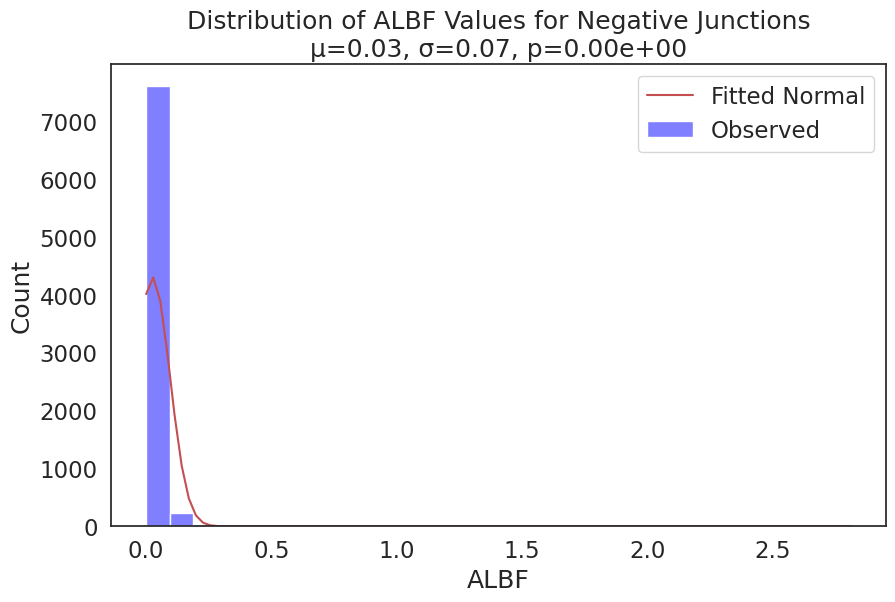

In [48]:
analyze_null_albf(albf_scores)

In [49]:
perc5=0.08536753799999997
perc1=0.278313481

albf_scores[albf_scores["ALBF"] > perc5]["true_label"].value_counts()

true_label
positive    7758
negative     398
Name: count, dtype: int64

In [50]:
7758/(398+7758), 398/(398+7758)

(0.9512015693967631, 0.04879843060323688)

In [53]:
# logistic sigmoid on ALBF values
albf_scores["sigmoid_ALBF"] = 1 / (1 + np.exp(-albf_scores["ALBF"]))

In [54]:
albf_scores

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label,sigmoid_ALBF
6799,0.190419,0.941792,6799,2.810358,0.000000,negative,1867,0,0.751373,1,0.943233
6798,0.280693,0.025431,6798,1.387880,0.000000,negative,1867,0,0.255263,1,0.800254
6800,0.339205,0.034806,6800,1.373499,0.000000,negative,1867,0,0.304399,1,0.797945
415,0.998706,0.978383,415,1.373440,0.000000,negative,37583,0,0.020323,1,0.797935
9150,0.000486,0.000120,9150,0.972405,0.000000,negative,9976,0,0.000366,1,0.725599
...,...,...,...,...,...,...,...,...,...,...,...
9443,0.292546,0.292563,9443,0.000944,0.003060,positive,11298,1,0.000017,0,0.500236
5540,0.277045,0.278351,5540,0.000700,0.001806,positive,54684,1,0.001306,0,0.500175
13415,0.157397,0.160561,13415,0.000662,0.023418,positive,23710,1,0.003164,0,0.500165
1946,0.299862,0.297916,1946,0.000622,0.000786,positive,44247,1,0.001947,0,0.500155


<Axes: xlabel='difference', ylabel='delta_est'>

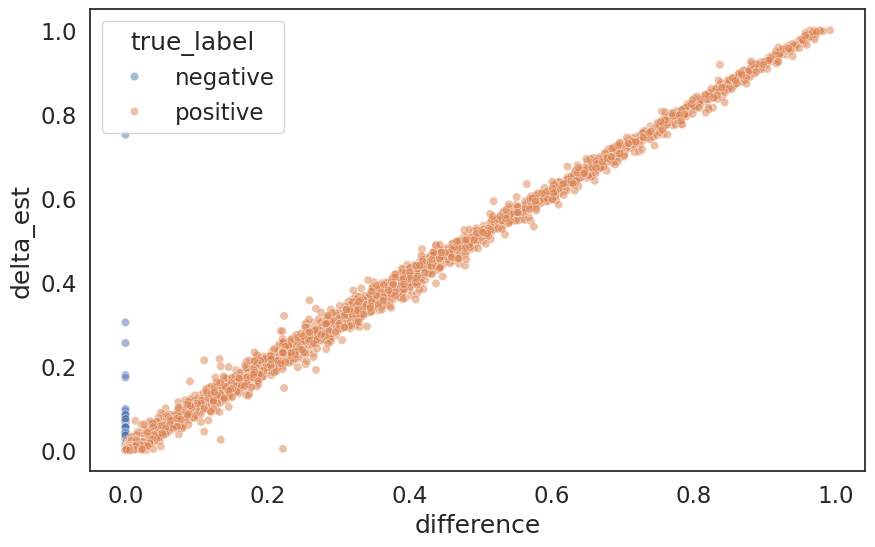

In [51]:
# let's plot difference column vs ALBF column for positive junctions under true_label
plt.figure(figsize=(10, 6))
sns.scatterplot(albf_scores, x='difference', y='delta_est', alpha=0.5, hue='true_label')

<Axes: xlabel='difference', ylabel='ALBF'>

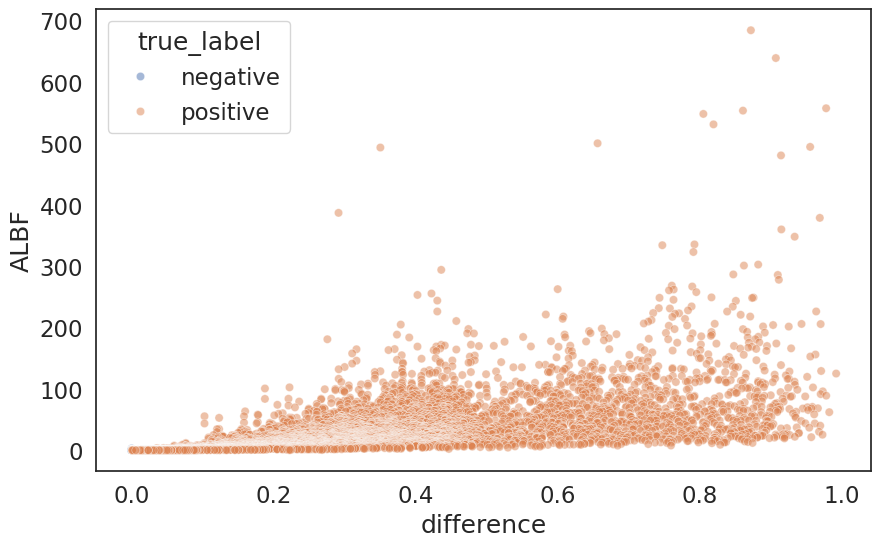

In [52]:
# let's plot difference column vs ALBF column for positive junctions under true_label
plt.figure(figsize=(10, 6))
sns.scatterplot(albf_scores, x='difference', y='ALBF', alpha=0.5, hue='true_label')

In [ ]:
# Empirical FDR = (Number of FALSE positives) / (Total number of positives)